# Study 3 — judge panels across budget regimes (appendix G.4.2)

Does a cheap, small-model-only judge panel, put through the same DIAL calibration as every
other real-data result, match human-only evaluation and a large or full panel? And how does
the answer move as either budget — human labels or LLM comparisons — becomes the scarce one?

Three sweeps, each drawn on the same 3 × 3 grid (datasets × judge panels) and in **two
metrics**: excess held-out log loss and Kendall's $\tau$ against the held-out human ranking.

| Figure | Sweep | Fixed |
|---|---|---|
| `fig_small_panel[_tau]` | human budget $n_H$ | as-collected LLM data |
| `fig_small_panel_llmbudget[_tau]` | LLM budget $n_L$ | $n_H = 300 / 80 / 60$ |
| `fig_intermediate_budget[_tau]` | human budget $n_H$ | $n_L = 2000 / 160 / 100$ |

The two metrics answer different questions and disagree in emphasis: log loss charges by the
probability gap and by how many test comparisons fall on a pair, so it is dominated by the
low-budget regime where the adaptive fit is unstable; $\tau$ charges every misordered pair
equally, which is the quantity a leaderboard actually reports.

Panels: `small6` (six open-weight judges, ≤ 9B each, 36.5B total), `large6` (≥ 20B each,
203B total), `all` (the paper's 21-judge panel). Methods: Human, Cons-Cal, DIAL-$\mu$ (raw)
= the plain GACV minimizer, and DIAL-$\mu$ = the $1/n_H$ endpoint margin.

Data generation lives in the runners, not here:

```bash
python -m experiments.real_data.endpoint_margin --seeds 50 --workers 6 \
    --panels all small6 large6 --out results/endpoint_margin_appendix
python -m experiments.real_data.intermediate_budget --seeds 50 --workers 8 \
    --out /tmp/dial-intermediate-budget-50
python -m experiments.real_data.intermediate_budget_validate --root /tmp/dial-intermediate-budget-50
```

The same 50 record splits underlie every figure, so the panels are directly comparable.
`python -m experiments.real_data.panel_budget --figures all` writes all six PDFs headlessly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from experiments.real_data.panel_budget import (
    DATASET_LABEL, INTERMEDIATE_NL, METHODS, METRIC, PANELS, RCPARAMS, ROOT,
    intermediate_data, panel_budget_data, panel_grid,
)

FIGURES = REPO / "figures"
summary = panel_budget_data(ROOT / "results" / "endpoint_margin_appendix")   # asserts all 50 seeds per cell
intermediate, seeds = intermediate_data(ROOT / "results" / "intermediate_budget")


def show(rows, name, metric, **kwargs):
    """Draw one panel grid inline and save it under the metric's file name."""
    with plt.rc_context(RCPARAMS):
        fig = panel_grid(rows, metric=metric, **kwargs)
        fig.savefig(FIGURES / f"{name}{'' if metric == 'excess' else '_tau'}.pdf", bbox_inches="tight")
        plt.show()


print(f"{len(summary)} budget/llm_budget rows, {len(intermediate)} intermediate rows ({seeds} seeds)")

408 budget/llm_budget rows, 171 intermediate rows (50 seeds)


## 1. Human budget at the collected LLM data

Where the small panel does and does not close the gap to `large6`, `all`, and human-only.

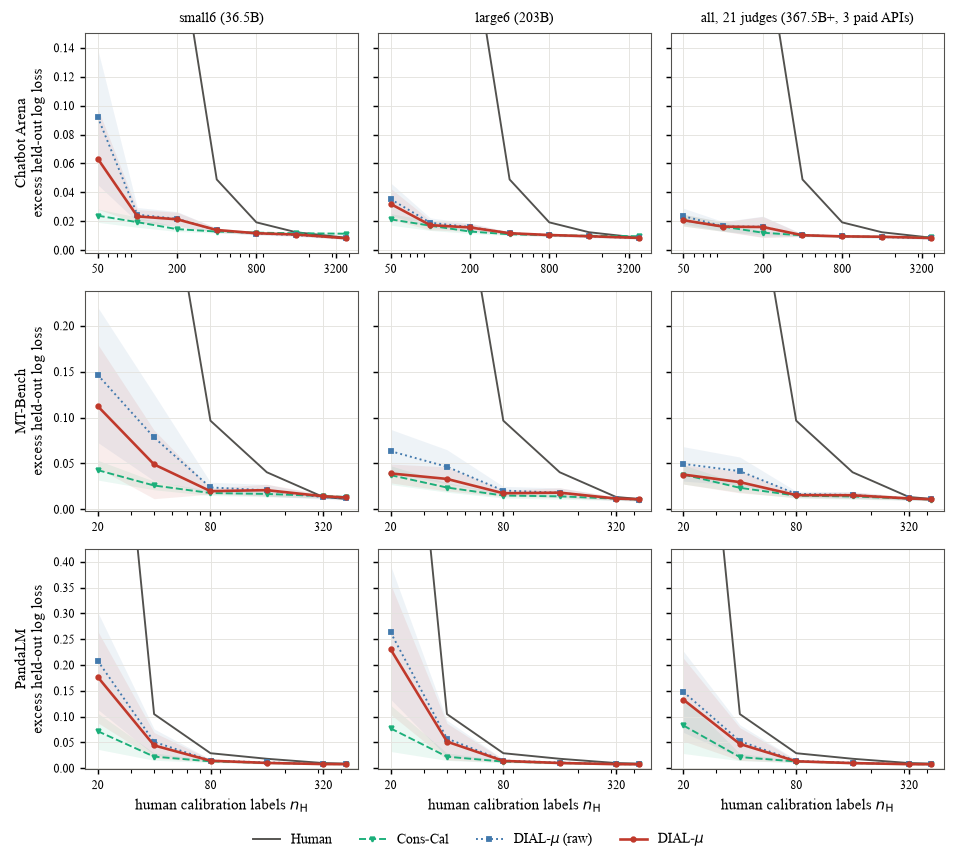

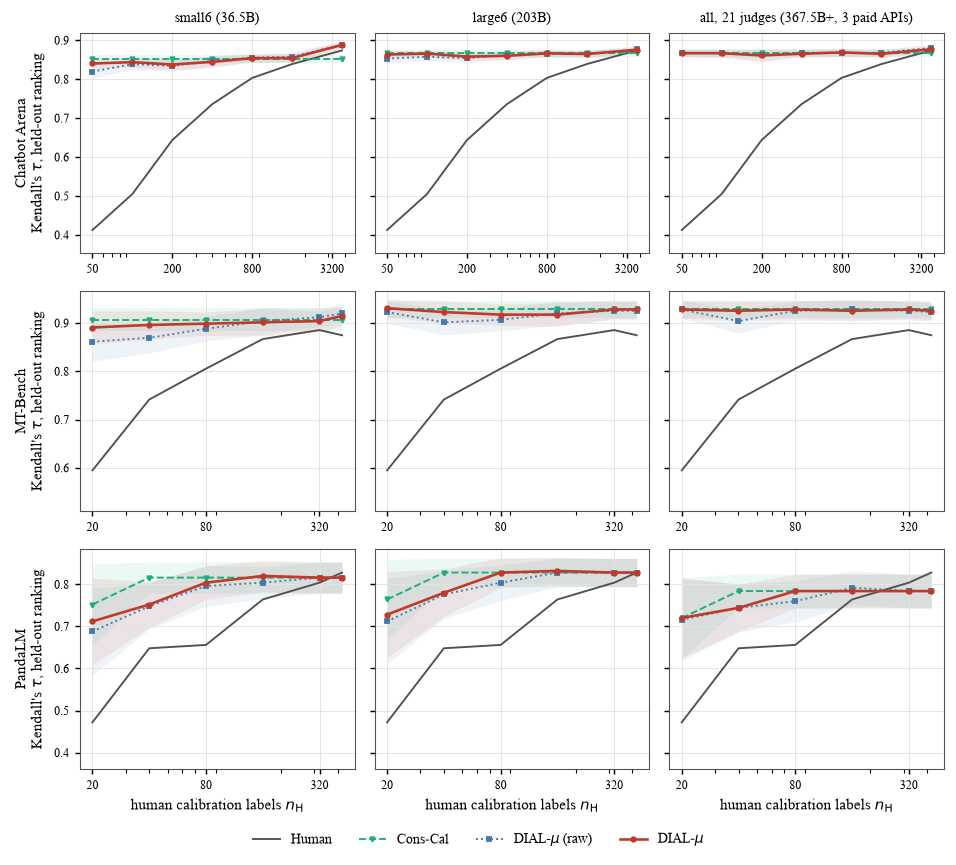

In [2]:
for metric in ("excess", "tau"):
    LABEL = METRIC[metric]["label"]
    show(summary[summary.sweep == "budget"], "fig_small_panel", metric,
         x_column="n_H", ylabel=lambda ds, _l=LABEL: f"{DATASET_LABEL[ds]}\n{_l}",
         xlabel=r"human calibration labels $n_{\mathrm{H}}$", methods=METHODS)

## 2. LLM budget at the default human budget

The reverse constraint: an imprecise LLM-only direction limits Cons-Cal, while DIAL-$\mu$ can
re-estimate $\mu$ from the human comparisons.

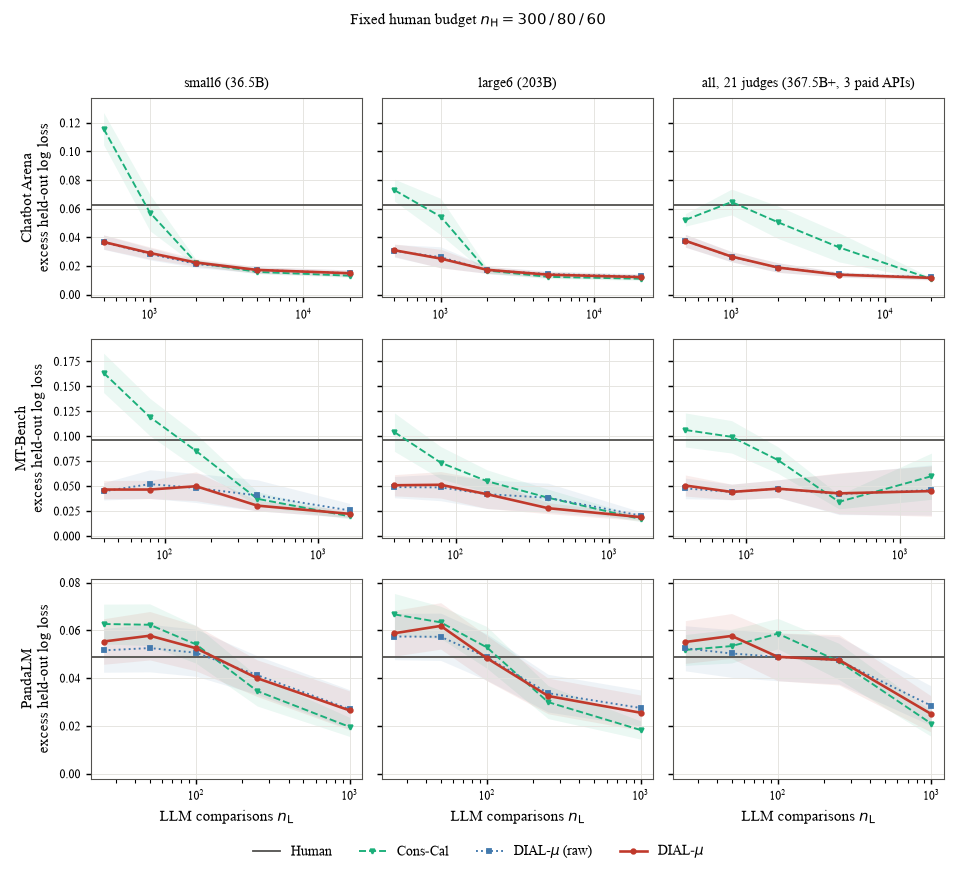

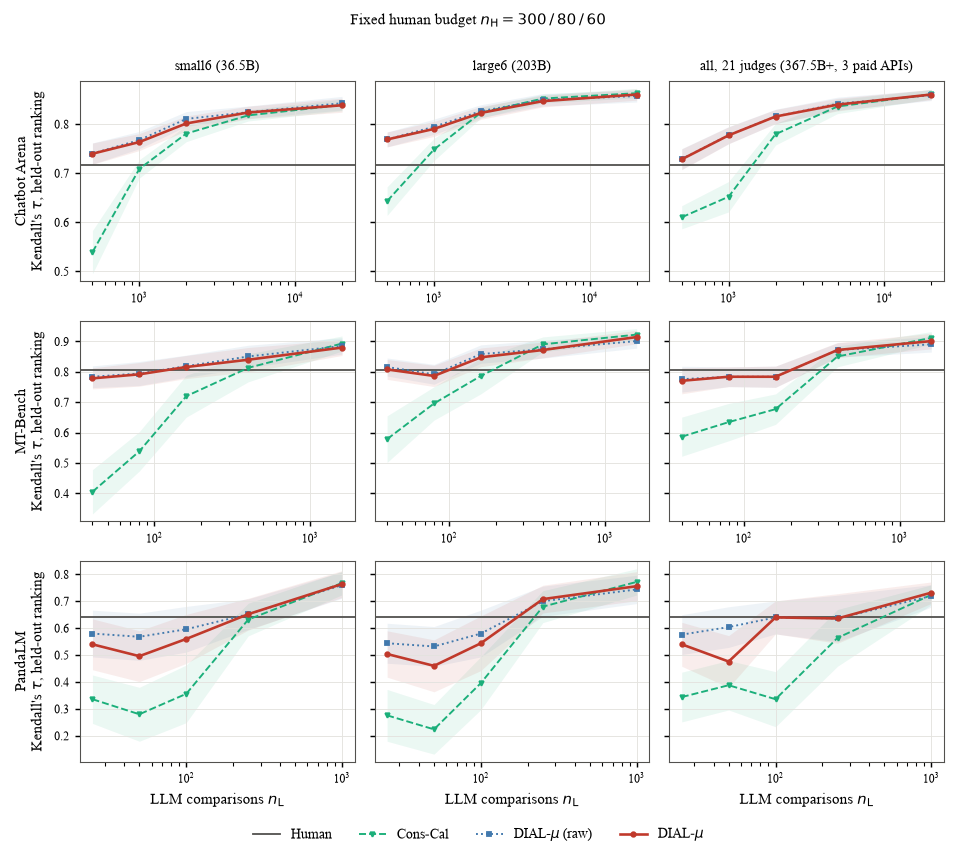

In [3]:
for metric in ("excess", "tau"):
    LABEL = METRIC[metric]["label"]
    show(summary[summary.sweep == "llm_budget"], "fig_small_panel_llmbudget", metric,
         x_column="level", ylabel=lambda ds, _l=LABEL: f"{DATASET_LABEL[ds]}\n{_l}",
         xlabel=r"LLM comparisons $n_{\mathrm{L}}$", methods=METHODS, flat=("human_only",),
         suptitle=r"Fixed human budget $n_{\mathrm{H}}=300\,/\,80\,/\,60$", xticks=False)

## 3. Human budget at a fixed intermediate LLM budget

The middle LLM level of sweep 2, which exposes the crossover between keeping the LLM-only
consensus direction (Cons-Cal) and letting human comparisons update it (DIAL-$\mu$).

The contrast between the two metrics is sharpest here. On log loss the axis is set by
DIAL-$\mu$'s penalty at the smallest budget, so its eventual 2–6× advantage is compressed
into the baseline; on $\tau$ the plateau of Cons-Cal — which fits only the scalar $\alpha$
and so cannot improve past the consensus misalignment floor — is immediately visible.

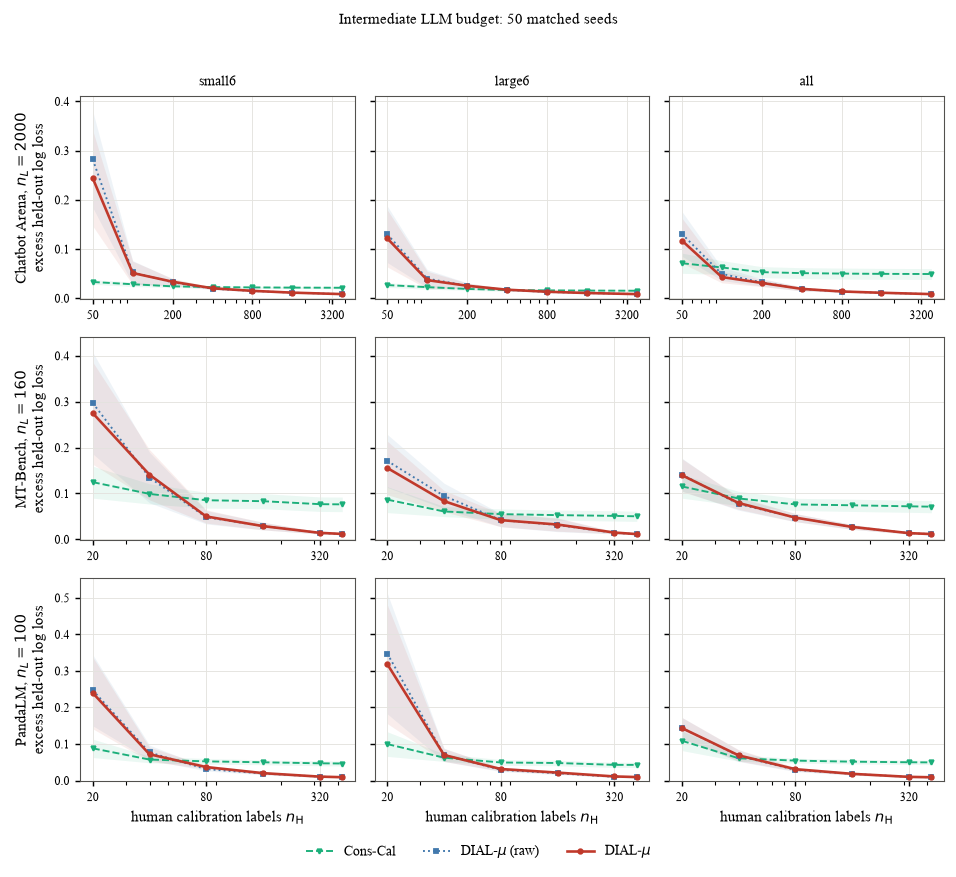

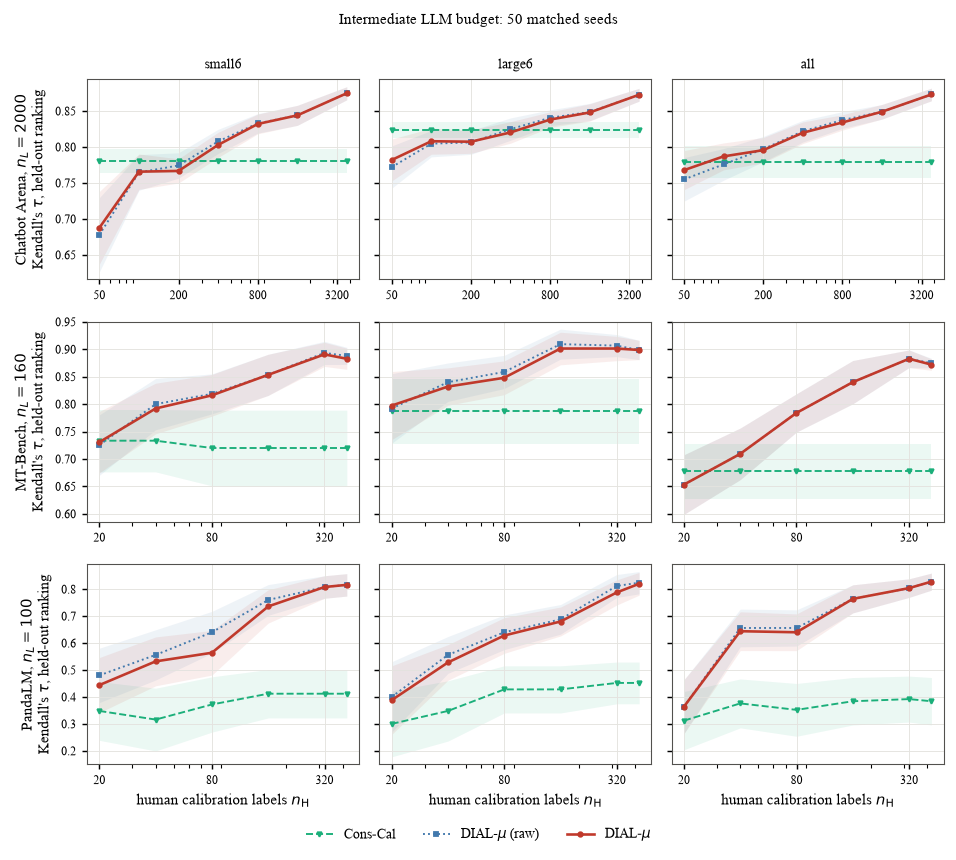

In [4]:
for metric in ("excess", "tau"):
    LABEL = METRIC[metric]["label"]
    show(intermediate, "fig_intermediate_budget", metric,
         x_column="n_H",
         ylabel=lambda ds, _l=LABEL: f"{DATASET_LABEL[ds]}, $n_L={INTERMEDIATE_NL[ds]}$\n{_l}",
         xlabel=r"human calibration labels $n_{\mathrm{H}}$", methods=METHODS[1:],
         titles=PANELS, suptitle=f"Intermediate LLM budget: {seeds} matched seeds")

## Full-pool comparison in both metrics

DIAL-$\mu$ against Cons-Cal at the largest tested human budget: the log-loss ratio, the
$\tau$ gain, and whether each beats Cons-Cal by more than two paired Monte Carlo standard
errors.

In [5]:
rows = []
for (ds, panel), g in intermediate.groupby(["dataset", "panel"]):
    top = g[g.n_H == g.n_H.max()].set_index("method")
    rows.append(dict(dataset=ds, panel=panel, n_H=round(g.n_H.max()),
                     loss_cons=top.loc["consensus_cal", "excess"], loss_dial=top.loc["dial_margin_1", "excess"],
                     loss_ratio=top.loc["consensus_cal", "excess"] / top.loc["dial_margin_1", "excess"],
                     tau_cons=top.loc["consensus_cal", "tau"], tau_dial=top.loc["dial_margin_1", "tau"],
                     tau_gain=top.loc["dial_margin_1", "tau"] - top.loc["consensus_cal", "tau"],
                     loss_signif=bool(top.loc["dial_margin_1", "delta_vs_cons"]
                                      < -2 * top.loc["dial_margin_1", "paired_mcse"])))
pd.DataFrame(rows).round(4)

,dataset,panel,n_H,loss_cons,loss_dial,loss_ratio,tau_cons,tau_dial,tau_gain,loss_signif
0,arena_33k,all,3802,0.0493,0.0085,5.7976,0.7796,0.8731,0.0935,True
1,arena_33k,large6,3802,0.0154,0.0085,1.8125,0.8234,0.8726,0.0493,True
2,arena_33k,small6,3802,0.0214,0.0085,2.5153,0.7808,0.8747,0.0939,True
3,mt_bench,all,422,0.0712,0.0115,6.1709,0.6773,0.8720,0.1947,True
4,mt_bench,large6,422,0.0502,0.0114,4.3863,0.7867,0.8987,0.1120,True
5,mt_bench,small6,422,0.0762,0.0118,6.4513,0.7200,0.8827,0.1627,True
6,pandalm,all,421,0.0496,0.0089,5.5813,0.3840,0.8280,0.4440,True
7,pandalm,large6,421,0.0428,0.0094,4.5396,0.4520,0.8200,0.3680,True
8,pandalm,small6,421,0.0466,0.0091,5.1380,0.4120,0.8160,0.4040,True


## Descriptive crossover locations

The first tested human budget at which DIAL-$\mu$ beats Cons-Cal by more than two paired Monte
Carlo standard errors, and keeps doing so at every higher budget (appendix Table 3). A post hoc
summary of these curves, not a calibrated test or a switching rule for new data.

In [6]:
def crossover(frame):
    out = []
    for (ds, panel), g in frame.groupby(["dataset", "panel"]):
        g = g[g.method == "dial_margin_1"].sort_values("n_H").set_index("n_H")
        better = g.delta_vs_cons < -2 * g.paired_mcse
        first = next((n for n in better.index if better.loc[n:].all()), None)
        out.append(dict(dataset=ds, panel=panel, n_L=INTERMEDIATE_NL[ds], crossover_n_H=first))
    return pd.DataFrame(out)

crossover(intermediate).pivot(index="dataset", columns="panel", values="crossover_n_H")

panel,all,large6,small6
dataset,,,
arena_33k,100.0,800.0,400.0
mt_bench,80.0,160.0,80.0
pandalm,80.0,80.0,80.0
